# 05 — Evaluation, error analysis, and comparison write-up

This notebook doesn't retrain anything — it loads the cross-validated results notebooks 03 and 04
already saved to `data/processed/`, puts them side by side, and does the part that's easy to skip but
is usually the most informative: looking at *specific* images where each model succeeded or failed, not
just the aggregate numbers.

In [1]:
import ast
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from ultralytics import YOLO

from src.models.patch_classifier import PatchClassifier
from src.models.sliding_window import detect

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
plt.rcParams["figure.dpi"] = 110

scenes = pd.read_csv(PROCESSED_DIR / "clean_manifest.csv")
scenes["boxes"] = scenes["boxes"].apply(ast.literal_eval)
scenes["scene_id"] = scenes["scene_id"].astype(str)

sw_results = pd.read_csv(PROCESSED_DIR / "sliding_window_cv_results.csv")
yolo_results = pd.read_csv(PROCESSED_DIR / "yolo_cv_results.csv")
sw_sweep_df = pd.read_csv(PROCESSED_DIR / "sliding_window_threshold_sweep.csv")
yolo_sweep_df = pd.read_csv(PROCESSED_DIR / "yolo_threshold_sweep.csv")
SW_THRESHOLD = float(sw_sweep_df.loc[sw_sweep_df["f1"].idxmax(), "threshold"])
YOLO_THRESHOLD = (
    float(yolo_sweep_df.loc[yolo_sweep_df["f1"].idxmax(), "threshold"]) if yolo_sweep_df["f1"].max() > 0 else 0.1
)

sw_results["scene_id"] = sw_results["scene_id"].astype(str)
yolo_results["scene_id"] = yolo_results["scene_id"].astype(str)
print(f"Sliding-window threshold: {SW_THRESHOLD}, YOLO threshold: {YOLO_THRESHOLD}")


Sliding-window threshold: 0.6, YOLO threshold: 0.1


## Side-by-side comparison

Both models were cross-validated on the exact same 19 scenes and 5 folds, and scored with the exact same
`match_detections` / `precision_recall` functions (IoU >= 0.3) — so this comparison is apples-to-apples,
not two different papers' self-reported numbers.

In [2]:
def summarize(df: pd.DataFrame, name: str) -> dict:
    tp, fp, fn = df["tp"].sum(), df["fp"].sum(), df["fn"].sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return {"model": name, "tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall}


summary = pd.DataFrame([
    summarize(sw_results, "Sliding-window CNN (from scratch)"),
    summarize(yolo_results, "YOLO11n (fine-tuned)"),
])
summary

,model,tp,fp,fn,precision,recall
0,Sliding-window CNN (from scratch),8,4203,13,0.001900,0.380952
1,YOLO11n (fine-tuned),4,34,17,0.105263,0.190476


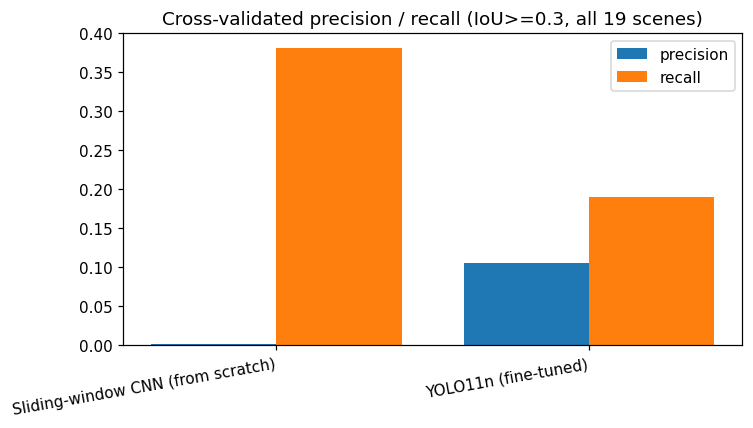

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(summary))
ax.bar([i - 0.2 for i in x], summary["precision"], width=0.4, label="precision")
ax.bar([i + 0.2 for i in x], summary["recall"], width=0.4, label="recall")
ax.set_xticks(list(x))
ax.set_xticklabels(summary["model"], rotation=10, ha="right")
ax.legend()
ax.set_title("Cross-validated precision / recall (IoU>=0.3, all 19 scenes)")
plt.tight_layout()
plt.show()

## Per-scene breakdown

Where specifically does each model succeed or fail? This is what points us at *which* images to look at
next, rather than staring at aggregate numbers.

In [4]:
merged = sw_results.merge(yolo_results, on="scene_id", suffixes=("_sw", "_yolo"))[
    ["scene_id", "tp_sw", "fp_sw", "fn_sw", "tp_yolo", "fp_yolo", "fn_yolo"]
]
merged

,scene_id,tp_sw,fp_sw,fn_sw,tp_yolo,fp_yolo,fn_yolo
0,1,1,357,0,0,0,1
1,2,0,286,1,0,0,1
2,6,1,204,0,0,0,1
3,12,1,303,0,0,0,1
4,4,0,135,1,0,0,1
5,9,1,378,0,0,1,1
6,14,0,104,1,0,1,1
7,17,1,208,1,1,10,1
8,3,0,104,1,0,1,1
9,10,1,70,1,1,4,1


## Visual error analysis

Load both trained models and look directly at a few informative scenes: one where a model gets a hit, one
both models miss, and the sliding-window model's typical failure mode (swamped by false positives).

**Read these pictures with one caution.** They use the *saved* models, each trained on 15 of the 19 scenes,
so a detection on a scene the model trained on is memorization, not held-out evidence. The cross-validated
table above (where every scene is scored by a model that never saw it) is the honest measure; the pictures
are for understanding what the boxes look like.

In [5]:
sw_model = PatchClassifier()
sw_model.load_state_dict(torch.load(MODELS_DIR / "sliding_window_classifier.pt", map_location="cpu"))
sw_model.eval()

yolo_model = YOLO(str(MODELS_DIR / "yolo_detector.pt"))


def show_both(scene_id: str, sw_threshold: float = SW_THRESHOLD, yolo_conf: float = YOLO_THRESHOLD, max_sw_boxes: int = 30):
    scene = scenes[scenes["scene_id"] == scene_id].iloc[0]
    image = Image.open(scene["image_path"])

    sw_dets = detect(sw_model, image, score_threshold=sw_threshold, nms_iou_threshold=0.2)
    yolo_result = yolo_model.predict(image, conf=yolo_conf, verbose=False)[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for ax, title in zip(axes, ["Sliding-window CNN", "YOLO11n"]):
        ax.imshow(image)
        for (x1, y1, x2, y2) in scene["boxes"]:
            ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2))
        ax.set_title(f"{title} — scene {scene_id}", fontsize=10)
        ax.axis("off")

    for det in sorted(sw_dets, key=lambda d: d.score, reverse=True)[:max_sw_boxes]:
        x1, y1, x2, y2 = det.box
        axes[0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=1, alpha=0.6))
    if len(sw_dets) > max_sw_boxes:
        axes[0].set_title(axes[0].get_title() + f" ({len(sw_dets)} raw detections, showing top {max_sw_boxes})", fontsize=8)

    for box in yolo_result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        axes[1].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2))
        axes[1].text(x1, y1 - 4, f"{box.conf.item():.2f}", color="red", fontsize=8)
    if len(yolo_result.boxes) == 0:
        axes[1].set_title(axes[1].get_title() + " (no detections)", fontsize=8)

    plt.tight_layout()
    plt.show()

### Case 1: does either model ever get a true positive?

YOLO scenes with a true positive: ['17', '10', '18', '8']
Sliding-window scenes with a true positive: ['1', '6', '12', '9', '17', '10', '16', '8']


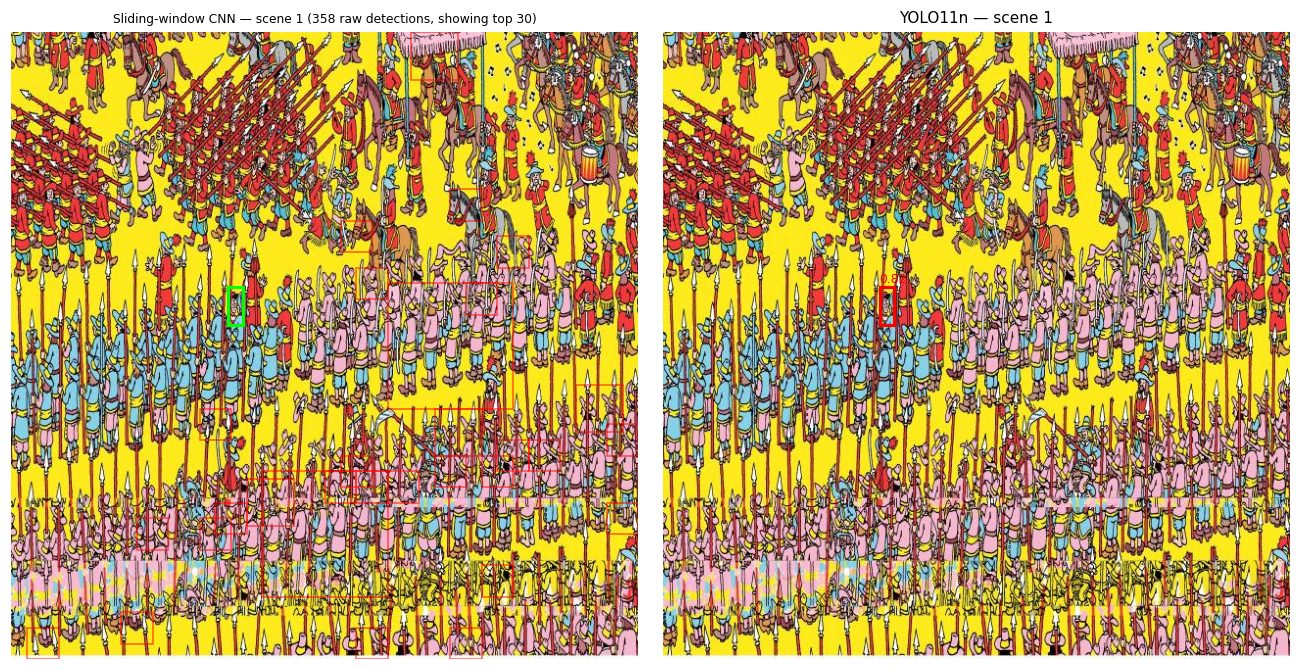

In [6]:
yolo_success_scenes = yolo_results[yolo_results["tp"] > 0]["scene_id"].tolist()
sw_success_scenes = sw_results[sw_results["tp"] > 0]["scene_id"].tolist()
print(f"YOLO scenes with a true positive: {yolo_success_scenes}")
print(f"Sliding-window scenes with a true positive: {sw_success_scenes}")

if sw_success_scenes:
    show_both(sw_success_scenes[0])
elif yolo_success_scenes:
    show_both(yolo_success_scenes[0])
else:
    print("Neither model produced a single true positive across all 19 cross-validated scenes.")
    print("Showing one scene anyway, to look at what each model predicts instead of a true match.")
    show_both(scenes["scene_id"].iloc[0])

### Case 2: a scene both models miss

Scenes both models fully miss: ['2', '4', '14', '3', '5', '13', '19', '7', '15']


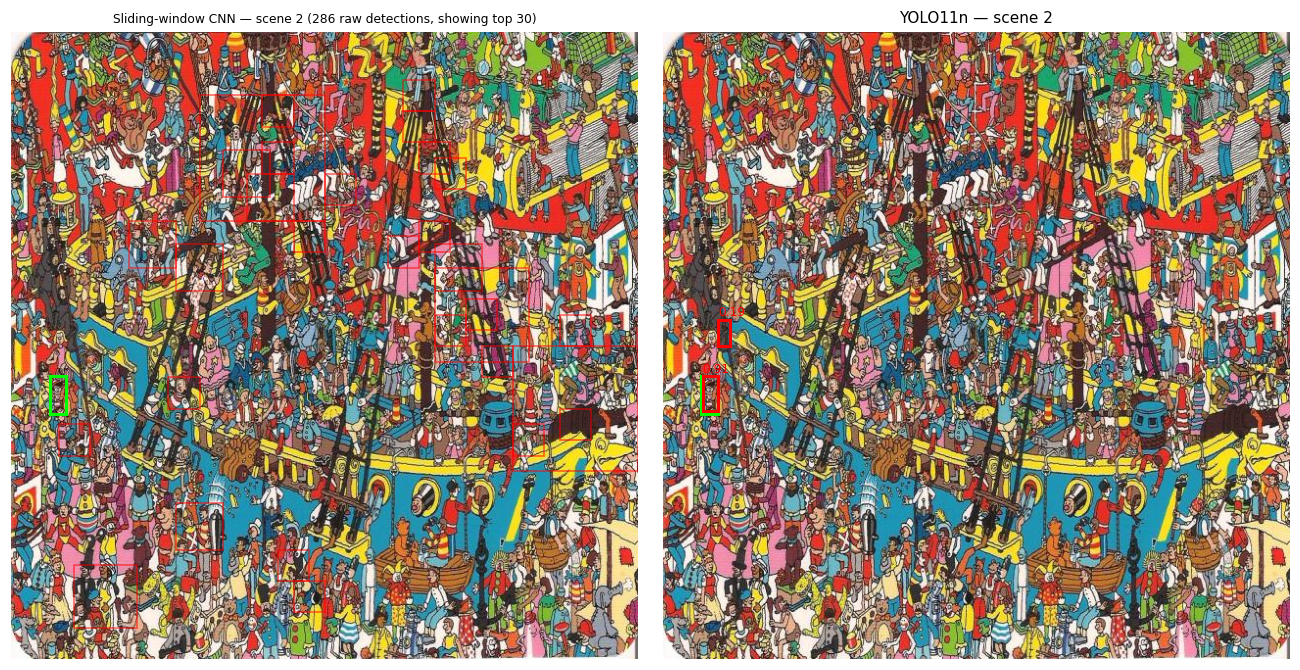

In [7]:
both_miss = merged[(merged["tp_sw"] == 0) & (merged["tp_yolo"] == 0) & (merged["fn_sw"] > 0)]["scene_id"].tolist()
print(f"Scenes both models fully miss: {both_miss}")
if both_miss:
    show_both(both_miss[0])

### Case 3: the sliding-window model's typical false-positive flood

Scene with the most sliding-window false positives: 19


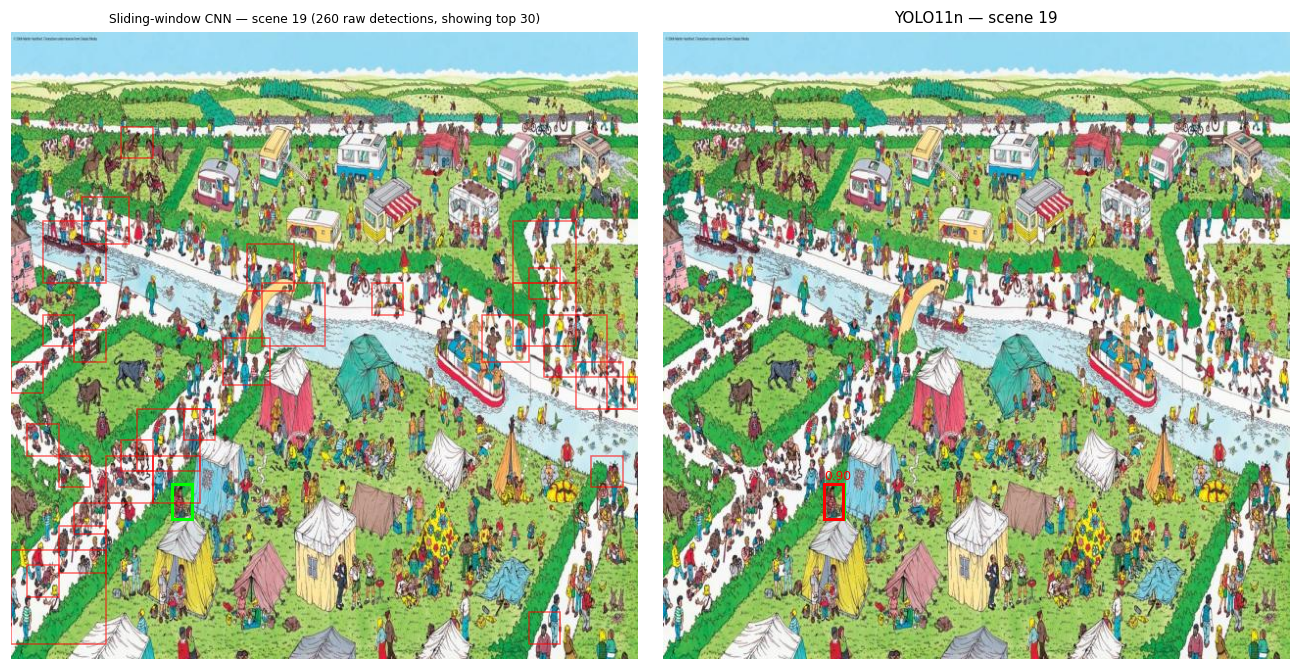

In [8]:
worst_fp_scene = sw_results.loc[sw_results["fp"].idxmax(), "scene_id"]
print(f"Scene with the most sliding-window false positives: {worst_fp_scene}")
show_both(worst_fp_scene)

## Practical comparison: size and speed

In [9]:
sw_params = sum(p.numel() for p in sw_model.parameters())
yolo_params = sum(p.numel() for p in yolo_model.model.parameters())

practical = pd.DataFrame([
    {"model": "Sliding-window CNN", "parameters": sw_params, "inference": "thousands of batched forward passes/image"},
    {"model": "YOLO11n", "parameters": yolo_params, "inference": "single forward pass/image"},
])
practical

,model,parameters,inference
0,Sliding-window CNN,98049,thousands of batched forward passes/image
1,YOLO11n,2590035,single forward pass/image


## Write-up: methodology, results, failure cases, what was learned

**Methodology.** Both detectors were trained and cross-validated on the same 19 hand-verified "hidden in a
crowd" scenes (notebook 01 filtered these out of a 65-image source dataset that turned out to be mostly
unrelated portrait closeups), using the same scene-level 5-fold split (notebook 02) and the same
IoU-matched precision/recall/localization-error metrics (`src/eval/metrics.py`) — never accuracy, and never
a framework's self-reported metric for one model without computing it for the other. Training data was
expanded beyond the raw scenes (notebook 02, Part 2): ~3,100 Hey-Waldo patches for the sliding-window
classifier, and copy-paste synthetic scenes for YOLO. Evaluation is always on real, unmodified held-out
scenes, and synthetic data only ever comes from a fold's *training* scenes.

**Results** (the table above is computed live from the saved cross-validation results):

| | found | false positives | missed | precision | recall | scenes with a hit |
|---|---|---|---|---|---|---|
| Sliding-window CNN | 8 | 4,203 | 13 | 0.002 | 0.38 | 8 / 19 |
| YOLO11n | 4 | 34 | 17 | 0.105 | 0.19 | 4 / 19 |

Neither is a working "find Waldo" tool. The sliding-window model finds Waldo more often but buries him
among ~220 false boxes per scene; YOLO produces few false alarms and localizes precisely when it fires
(mean error 2.5 px vs 10.1 px), but finds him in only about one scene in five. Nine scenes are missed by
both. Compared with the first pass (before Part 2), the sliding-window model's recall rose from about 0.05
to 0.38 with precision unchanged, and YOLO went from zero true positives to four. These are measured
changes, but this project ran no ablations, so *which* addition is responsible is not established.

**Caveats that matter.** (1) There are only 21 Waldo boxes: 4 vs 8 hits is a small sample, and the per-fold
YOLO results range from mAP ≈ 0 to 0.40, so the ranking of the two models on any one metric is not solid.
(2) YOLO's operating point is an untuned fallback (`conf=0.1`): the fold-0 sweep found no true positive at
any threshold. (3) The sliding-window threshold was tuned on fold 0 only. (4) The saved models are the
fold-0 models, trained on 15 of the 19 scenes.

**Failure modes.**
- *Sliding-window CNN*: over-fires. Scores for Waldo windows and background windows overlap almost
  completely (no threshold gives a usable trade-off), and the classifier's training crops (clean,
  centered) look nothing like the arbitrary crops a sliding window produces — a likely cause, not a tested
  one. Hard-negative mining (225 mined negatives) changed nothing (fold 0: precision 0.003 → 0.002,
  recall 0.75 → 0.75).
- *YOLO11n*: under-generalizes. In every fold the validation box loss is well above the training box loss
  (about 1.8× to 4×), and results depend heavily on which scenes are held out. It learns something
  transferable in some folds (fold 2: precision 1.00, recall 0.38 on its held-out scenes) and nothing in
  others.

**What was learned** (mapped to the project's learning objectives):
- *IoU, NMS, sliding windows*: implemented from scratch (`src/eval/box_utils.py`,
  `src/models/sliding_window.py`), not imported from a detection framework.
- *Why detection metrics differ from accuracy*: with ~1 positive window per ~2,300 (notebook 01), a
  detector can look fine under accuracy while being useless — the sliding-window model's 0.002 precision is
  exactly that case.
- *Scene-level splitting*: checked explicitly on the raw split (notebook 01) and on our k-fold assignment
  (notebook 02), and respected when generating synthetic data (only from a fold's training scenes).
- *Sliding window vs YOLO*: both built on the same data and evaluation code, so the comparison is
  controlled — and shows they fail differently (many false alarms vs many misses), and that YOLO is ~32×
  faster per image.
- *Small objects in a low-data regime*: Waldo covers ~0.14% of a scene (median, notebook 01), and 19 scenes
  is very little. What each addition bought is visible above, but neither closes the gap.

**What would be worth trying next** (hypotheses, none tested here): more real, correctly-boxed scenes
remain the most direct lever. Resolution is another: in scene 1, for example, Waldo is 15×39 px in the
640×640 working image but 48×76 px at native resolution (the Hey-Waldo scans, already used here for
crops), so training and running YOLO on native-resolution tiles may help small-object detection. A final
model trained on all 19 scenes rather than 15, and a YOLO threshold chosen on properly pooled validation
predictions, would also make the deployed model and its operating point better grounded.